## ***Library***

In [ ]:
pip install "gymnasium[all]"

In [ ]:
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np
import time
import pandas as pd

## ***Taxi Environment***

In [ ]:
class TaxiEnvironment:
    """
    Wraps the Gymnasium Taxi-v3 environment.
    Acts as the single point of contact for the simulator.
    """
    def __init__(self):
        # Initialize the environment
        self._env = gym.make("Taxi-v3", render_mode="ansi")

        # Public attributes required for planning
        self.n_states = self._env.observation_space.n  #500
        self.n_actions = self._env.action_space.n # 6 Movements: Up, Down, Right, Left, Ride, Descend
        # The true transition model
        self.P = self._env.unwrapped.P  # Transition probabilities and rewards for each (state + action)

    def reset(self):
        """Resets the environment and returns the initial state."""
        state, info = self._env.reset()
        return state

    def step(self, action):
        """Executes one step and returns (next_state, reward, done, info)."""
        # Reward(-1, +20)
        next_state, reward, terminated, truncated, info = self._env.step(action) # execute action
        done = terminated or truncated
        return next_state, reward, done, info

    def render(self):
        """Returns the visual representation of the environment."""
        return self._env.render()


## **Value Iteration**

In [10]:
class ValueIterationAgent:
    def __init__(self, env, gamma=0.9, theta=1e-5):
        self.env = env
        self.gamma = gamma
        self.theta = theta

        self.value_function = np.zeros(self.env.n_states)       #carry value of each sate
        self.policy = np.zeros(self.env.n_states, dtype=int)    #carry what are the best action you can take in each state as thsi is stochastic policy
        self.convergence_history = []                           # store delta for each iteration

    def value_iteration(self):
        iteration = 0

        while True:
            delta = 0

            for state in range(self.env.n_states):
                v = self.value_function[state]

                action_values = []

                for action in range(self.env.n_actions):# we have actions from 0->5 as we have 6 actions in the environment
                    q_value = 0

                    for prob, next_state, reward, done in self.env.P[state][action]:#list of tubles (probability, next_state, reward, done) for each action we can do from state where the list carry all possible next states i can translate to them from a certain action and the probability to go to each state and the reward of going to that state and if it is done or not
                      if done:
                          q_value += prob * reward
                      else:
                          q_value += prob * (
                              reward + self.gamma * self.value_function[next_state]  #Bellman
                          )
                    action_values.append(q_value)

                best_value = max(action_values)
                self.value_function[state] = best_value

                delta = max(delta, abs(v - best_value))

            self.convergence_history.append(delta)
            iteration += 1

            if delta < self.theta:#delta tell you the maximum change in value function across all states in the current iteration if it is less than theta we can say that we have converged and we can stop the iteration
                break

        # Extract policy
        for state in range(self.env.n_states):#0->499 as we have 500 states
            action_values = []

            for action in range(self.env.n_actions): #calculate the Q for each action we can do from six actions as this is the stochastic environment as in one action we can go to may other states
                q_value = 0
                for prob, next_state, reward, done in self.env.P[state][action]:#for each action see what are the possible states we can go to and use probability to go to next sate and the value of next sate to calculate the Q value of the action
                        if done:
                            q_value += prob * reward
                        else:
                            q_value += prob * (
                                reward + self.gamma * self.value_function[next_state]
                            )

                action_values.append(q_value)

            self.policy[state] = np.argmax(action_values)# at each state pick the best action we can do get index of the best action and store it in the policy
        return iteration


In [ ]:
env = TaxiEnvironment()# you have a fully initialized environment with all the states and actions and the transition model
agent = ValueIterationAgent(env, gamma=0.9, theta=1e-5)

agent.value_iteration()

print(agent.value_function[:10])
print(agent.policy[:10])
print(agent.convergence_history[:10])


[17.          1.62261467  7.7147      2.9140163  -4.99684549  1.62261467
 -4.99684549 -3.13696226  1.62261467 -2.37440252]
[4 4 4 4 0 0 0 0 0 0]
[np.float64(20.0), np.float64(18.0), np.float64(16.2), np.float64(14.580000000000002), np.float64(13.122000000000002), np.float64(11.809800000000003), np.float64(10.628820000000003), np.float64(9.565938000000003), np.float64(8.609344200000002), np.float64(5.540112992700002)]


```
 delta decrease as you go through many iterations as value of each state will become constant and not change at all.
```




## **Policy Iteration**

In [9]:
class PolicyIterationAgent:
    def __init__(self, env, gamma=0.9, theta=1e-5):
        self.env = env
        self.gamma = gamma
        self.theta = theta

        self.n_states = env.n_states
        self.n_actions = env.n_actions
        self.P = env.P

        self.value_function = np.zeros(self.env.n_states)
        self.policy = np.zeros(self.env.n_states, dtype=int)
        self.n_policy_changes = 0

    def policy_evaluation(self):
        while True:
            delta = 0

            for state in range(self.n_states):
                old_value = self.value_function[state]

                action = self.policy[state]
                transitions = self.P[state][action]#list of tubles (probability, next_state, reward, done) for the action we are taking in the current policy from state

                new_value = 0

                for prob, next_state, reward, done in transitions:
                    if done:
                        new_value += prob * reward
                    else:
                        new_value += prob * (reward + self.gamma * self.value_function[next_state])

                self.value_function[state] = new_value

                delta = max(delta, abs(new_value - old_value))#check about what is the max modification in the value function across all states in the current iteration

            if delta < self.theta:
                break

    def policy_improvement(self):
      policy_stable = True

      for state in range(self.n_states):
          old_action = self.policy[state]

          best_action = None
          best_value = float('-inf')

          for action in range(self.n_actions):
              action_value = 0

              transitions = self.P[state][action]

              for prob, next_state, reward, done in transitions:
                  if done:
                      action_value += prob * reward
                  else:
                      action_value += prob * (reward + self.gamma * self.value_function[next_state])

              if action_value > best_value:
                  best_value = action_value
                  best_action = action

          if best_action != old_action:
              policy_stable = False
              self.n_policy_changes += 1

          self.policy[state] = best_action

      return policy_stable

    def run_policy_iteration(self):
        iterations = 0

        while True:
            iterations += 1
            self.policy_evaluation()
            stable = self.policy_improvement()

            if stable:
                break

        return iterations

In [ ]:
env = TaxiEnvironment()
policy = PolicyIterationAgent(env, .9)
iter = policy.run_policy_iteration()
print(iter)


17


## **Visualization**

In [ ]:
class Visualizer:
    def __init__(self):
        pass

    def plot_convergence(self , histories ,labels):
        """
        histories: list of lists (each one convergence history)
        gammas: list of gamma values
        """
        for history , label in zip (histories , labels):
            plt.plot(history , label = label)

        plt.xlabel("Iteration")
        plt.ylabel("Delta")
        plt.yscale("log")
        plt.legend()
        plt.grid(True)
        plt.title("Convergence History")
        plt.show()


    def plot_gamma_comparison(self , gammas , vi_iter , pi_iter):
        x = np.arange(len(gammas))
        width = 0.4

        plt.bar(x-width/2 , vi_iter , width , label = "value iteration" )
        plt.bar(x+width/2 , pi_iter ,width , label = "policy iteration" )

        plt.xticks(x, [str(g) for g in gammas])
        plt.xlabel("Gamma")
        plt.ylabel("Iterations")
        plt.legend()
        plt.grid(True)
        plt.title("Gamma Comparison")
        plt.show()

    def plot_value_function(self , value_function ):

        grid = value_function[:25].reshape(5,5)

        plt.imshow(grid, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.title("Value Function Heatmap (First 25 States)")
        plt.show()


    def plot_policy_grid(self , policy):
        arrows = {
            0: "↑",
            1: "↓",
            2: "→",
            3: "←",
            4: "P",
            5: "D"
        }

        grid = policy[:25].reshape(5,5)

        fig, ax = plt.subplots()
        for i in range(5):
            for j in range(5):
                ax.text(j, i, arrows[grid[i, j]], ha="center", va="center", color="black")

        ax.set_xticks(range(5))
        ax.set_yticks(range(5))
        plt.title("Policy Grid (↑ ↓ → ← P=Pickup, D=Dropoff)")
        plt.gca().invert_yaxis()
        plt.show()

    def plot_value_difference(self, v1, v2):
        diff = np.abs(v1 - v2)[:25].reshape(5, 5)

        plt.imshow(diff, cmap="hot")
        plt.colorbar()
        plt.title("Difference: Real vs Learned Value")

        plt.show()
    def plot_policy_similarity(self, p1, p2):

        p1 = np.array(p1)
        p2 = np.array(p2)

        diff = (p1 != p2).astype(int)

        grid = diff[:25].reshape(5, 5)

        plt.imshow(grid, cmap="hot")
        plt.colorbar(label="0 = Same Policy, 1 = Different Policy")
        plt.title("Policy Similarity: Real vs Learned")
        plt.show()

## Planner

In [ ]:
class Planner:
  # Orchestrator for running, tracking, and comparing model-based planning algorithms.
  def __init__(self, env, gamma=0.9, theta=1e-5):
    self.env = env
    self.gamma = gamma
    self.theta = theta

    self.vi_agent = None
    self.pi_agent = None
    self.vi_metrics =  None
    self.pi_metrics = None

  def run_value_iteration(self):
    #tracks time & convergence
    start_time = time.time()
    self.vi_agent = ValueIterationAgent(self.env, gamma=self.gamma, theta=self.theta)
    self.vi_agent.value_iteration()

    total_time = time.time() - start_time

    self.vi_metrics = {
            'iterations': len(self.vi_agent.convergence_history),
            'time_seconds': total_time,
            'policy': self.vi_agent.policy.copy(),
            'value_function': self.vi_agent.value_function.copy(),
            'convergence_deltas': self.vi_agent.convergence_history.copy()
        }
    return self.vi_metrics

  def run_policy_iteration(self):
    #tracks time & convergence
    start_time = time.time()
    self.pi_agent = PolicyIterationAgent(self.env, gamma=self.gamma, theta=self.theta)
    iterations = self.pi_agent.run_policy_iteration()

    total_time = time.time() - start_time

    self.pi_metrics = {
            'iterations': iterations,
            'time_seconds': total_time,
            'policy': self.pi_agent.policy.copy(),
            'value_function': self.pi_agent.value_function.copy(),
        }
    return self.pi_metrics

  def compare_agents(self):
    #run iterations if not run
    if self.vi_metrics is None:
        self.run_value_iteration()
    if self.pi_metrics is None:
        self.run_policy_iteration()
    # Policy comparison
    policies_match = np.array_equal(self.vi_metrics['policy'], self.pi_metrics['policy'])

    # Value function comparison (Mean Absolute Error)
    value_diff = np.mean(np.abs(self.vi_metrics['value_function'] - self.pi_metrics['value_function']))

    summary = {
        'Value Iteration': {
            'iterations': self.vi_metrics['iterations'],
            'time_elapsed (s)': round(self.vi_metrics['time_seconds'], 2)
        },
        'Policy Iteration': {
            'iterations': self.pi_metrics['iterations'],
            'time_elapsed (s)': round(self.pi_metrics['time_seconds'], 2)
        },
        'Comparison': {
            'policies_identical': bool(policies_match),
            'mean_abs_value_diff': round(value_diff, 2)
        }
    }
    return summary

  """def print_comparison_report(self):
    summary = self.compare_agents()
    df = pd.DataFrame.from_dict(summary,orient='index')
    return df"""
  def print_comparison_report(self):
    summary = self.compare_agents()

    # Performance metrics
    perf_df = pd.DataFrame({
        'Algorithm': ['Value Iteration', 'Policy Iteration'],
        'Iterations': [summary['Value Iteration']['iterations'],
                      summary['Policy Iteration']['iterations']],
        'Time (s)': [summary['Value Iteration']['time_elapsed (s)'],
                    summary['Policy Iteration']['time_elapsed (s)']]
    })

    # Comparison metrics
    comp_df = pd.DataFrame({
        'Metric': ['Policies Identical', 'Mean Abs Value Diff'],
        'Value': [summary['Comparison']['policies_identical'],
                 summary['Comparison']['mean_abs_value_diff']]
    })

    print("\nPerformance Comparison")
    display(perf_df.style.set_table_attributes('style="font-size: 12px"'))

    print("\nAlgorithm Agreement")
    display(comp_df.style.set_table_attributes('style="font-size: 12px"'))


###Test agents

In [ ]:
env = TaxiEnvironment()

# Test Value Iteration
vi_agent = ValueIterationAgent(env, gamma=0.9, theta=1e-5)
vi_agent.value_iteration()
print(f"VI converged in {len(vi_agent.convergence_history)} iterations")
print(f"Policy sample: {vi_agent.policy[:10]}")

# Test Policy Iteration
pi_agent = PolicyIterationAgent(env, gamma=0.9, theta=1e-5)
pi_iters = pi_agent.run_policy_iteration()
print(f"PI converged in {pi_iters} iterations")
print(f"Policies match: {np.array_equal(vi_agent.policy, pi_agent.policy)}")

VI converged in 13 iterations
Policy sample: [4 4 4 4 0 0 0 0 0 0]
PI converged in 17 iterations
Policies match: True


###Compare agents

In [ ]:
planner = Planner(env, gamma=0.9, theta=1e-5)
# comparison
planner.print_comparison_report()


Performance Comparison


,Algorithm,Iterations,Time (s)
0,Value Iteration,13,0.040000
1,Policy Iteration,17,0.150000



Algorithm Agreement


,Metric,Value
0,Policies Identical,True
1,Mean Abs Value Diff,0.000000


In [ ]:
gammas = [0.5, 0.9, 0.99]

vi_histories = []
vi_iters = []
pi_iters = []
policies_vi = []
policies_pi = []
policies_match = []


for gamma in gammas:
    env = TaxiEnvironment()

    # Value Iteration
    vi_agent = ValueIterationAgent(env, gamma=gamma)
    iters = vi_agent.value_iteration()

    vi_histories.append(vi_agent.convergence_history)
    vi_iters.append(iters)
    policies_vi.append(vi_agent.policy)

    # Policy Iteration
    pi_agent = PolicyIterationAgent(env, gamma=gamma)
    iters = pi_agent.run_policy_iteration()

    pi_iters.append(iters)
    policies_pi.append(pi_agent.policy)

    policies_match.append(np.array_equal(vi_agent.policy, pi_agent.policy))

In [ ]:
for g, vi_i, pi_i, p1, p2 in zip(gammas, vi_iters, pi_iters, policies_vi, policies_pi):
    print(f"Gamma={g}")
    print("VI iterations:", vi_i)
    print("PI iterations:", pi_i)
    print(f"Gamma {g}: Policies identical = {np.array_equal(p1, p2)}")
    print("-"*30)

df = pd.DataFrame({
"Gamma": gammas,
"VI Iterations":  vi_iters,
"PI Iterations": pi_iters,
"Policies Identical": policies_match
})
display(df)

Gamma=0.5
VI iterations: 15
PI iterations: 17
Gamma 0.5: Policies identical = True
------------------------------
Gamma=0.9
VI iterations: 13
PI iterations: 17
Gamma 0.9: Policies identical = True
------------------------------
Gamma=0.99
VI iterations: 13
PI iterations: 17
Gamma 0.99: Policies identical = True
------------------------------


,Gamma,VI Iterations,PI Iterations,Policies Identical
0,0.50,15,17,True
1,0.90,13,17,True
2,0.99,13,17,True


### **Notes**
- Fast convergence, lower discount factor leads to shorter planning horizon
- Balanced discounting, stable optimal policy reached                          
- Long-term planning, slightly slower value propagation but same optimal policy


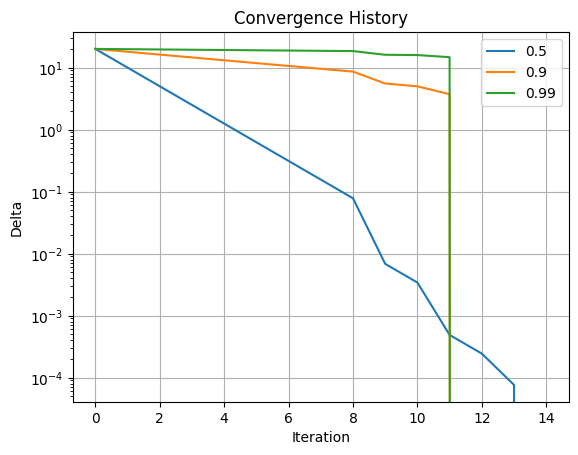

In [ ]:
vis = Visualizer()
vis.plot_convergence(vi_histories, gammas)

**The convergence curves show that the discount factor (γ) strongly affects speed.
- For γ = 0.5, convergence is fast because the agent focuses on immediate rewards, making updates quick and stable.

- As γ increases to 0.9, convergence becomes slower since the agent considers future rewards, requiring more propagation steps.

- At γ = 0.99, convergence is the slowest initially, with a flat start followed by a sharp drop, due to heavy reliance on long-term rewards and slower value propagation.

Overall, higher γ values slow early convergence but improve long-term accuracy, while lower γ gives faster but more short-sighted learning.**

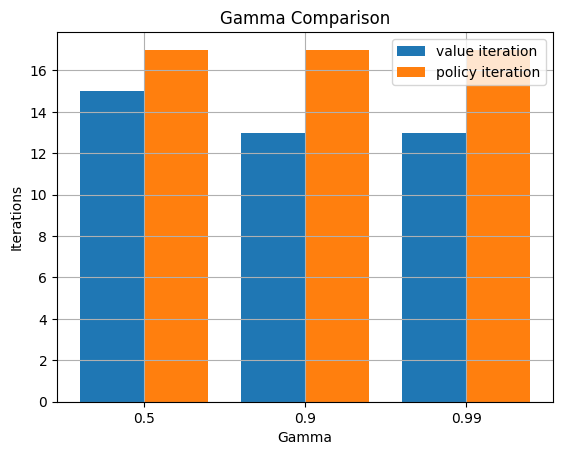

In [ ]:
vis.plot_gamma_comparison(gammas, vi_iters, pi_iters)


**Value Iteration converges faster (13–15 iterations) compared to Policy Iteration (17 iterations).

This is because Value Iteration directly applies the Bellman optimal update each step, while Policy Iteration spends extra effort on policy evaluation, making each iteration more computationally expensive.**

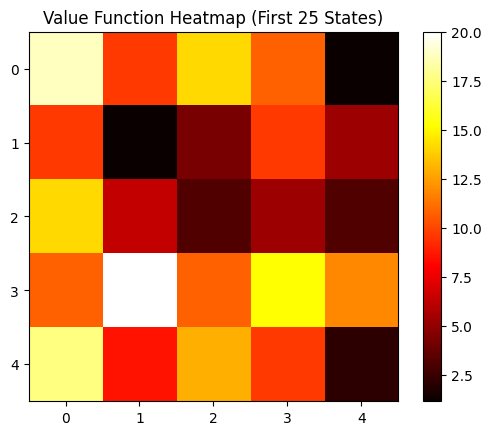

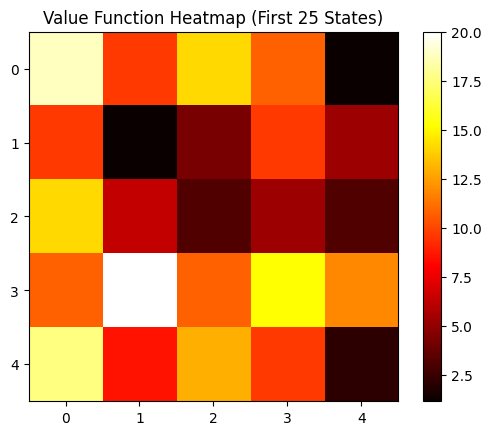

In [ ]:
vis.plot_value_function(vi_agent.value_function)
vis.plot_value_function(pi_agent.value_function)

**"The identical heatmaps show that both algorithms reached the same optimal values. Bright cells represent high-value states closer to the goal, while darker cells indicate low-value states or areas further from rewards."**



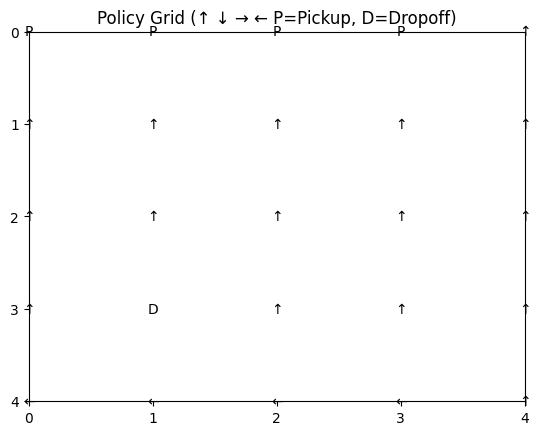

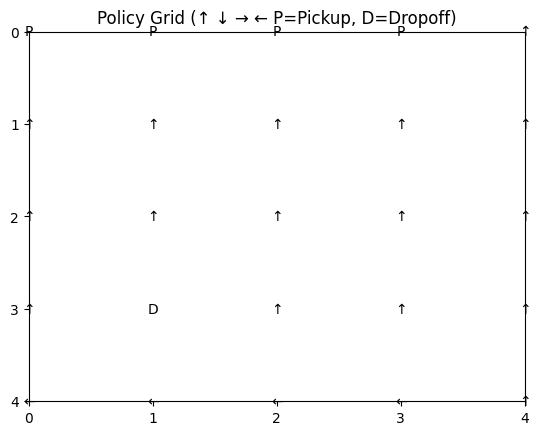

In [ ]:
vis.plot_policy_grid(vi_agent.policy)
vis.plot_policy_grid(pi_agent.policy)


**"Both algorithms produced the same optimal policy grid. The arrows show the best action for each state, guiding the agent toward the Pickup (P) and Drop-off (D) locations efficiently."**

# **Analysis**

#### **Convergence Analysis**

The convergence curves show that the discount factor (γ) strongly affects speed.
- For γ = 0.5, convergence is fast because the agent focuses on immediate rewards, making updates quick and stable.

- As γ increases to 0.9, convergence becomes slower since the agent considers future rewards, requiring more propagation steps.

- At γ = 0.99, convergence is the slowest initially, with a flat start followed by a sharp drop, due to heavy reliance on long-term rewards and slower value propagation.

Overall, higher γ values slow early convergence but improve long-term accuracy, while lower γ gives faster but more short-sighted learning.

#### **Value Iteration vs Policy Iteration**

Value Iteration converges faster (13–15 iterations) compared to Policy Iteration (17 iterations).

This is because Value Iteration directly applies the Bellman optimal update each step, while Policy Iteration spends extra effort on policy evaluation, making each iteration more computationally expensive.


In [4]:
# Section 5.1: Learned Transition Model
class TransitionModel:
    """
    Learns an approximation of the environment dynamics through interaction.
    Matches the structure of env.P for seamless integration with agents.
    """
    def __init__(self, n_states=500, n_actions=6):
        self.n_states = n_states
        self.n_actions = n_actions
        # Dictionary structure mimicking Gymnasium's P[s][a]
        self.P = {s: {a: [] for a in range(n_actions)} for s in range(n_states)}

        # Internal counters for MLE (Maximum Likelihood Estimation)
        self._counts = np.zeros((n_states, n_actions, n_states))
        self._rewards = np.zeros((n_states, n_actions, n_states))
        self._terminations = np.zeros((n_states, n_actions, n_states), dtype=bool)

    def update(self, s, a, r, s_next, done):
        """
        Updates the model based on a single experience tuple (s, a, r, s_next).
        This implements the Online Model Learning requirement.
        """
        self._counts[s][a][s_next] += 1
        self._rewards[s][a][s_next] = r
        self._terminations[s][a][s_next] = done

        # Re-calculate transition probabilities for this state-action pair
        total_transitions = np.sum(self._counts[s][a])

        new_entry = []
        # Find all states that have been visited from (s, a)
        visited_next_states = np.where(self._counts[s][a] > 0)[0]

        for next_s in visited_next_states:
            prob = self._counts[s][a][next_s] / total_transitions
            reward = self._rewards[s][a][next_s]
            is_done = self._terminations[s][a][next_s]

            # Format: (probability, next_state, reward, is_done)
            new_entry.append((prob, next_s, reward, is_done))

        # Update the accessible model for the planning agents
        self.P[s][a] = new_entry

In [ ]:
env = TaxiEnvironment()
model = TransitionModel()

for episode in range(5000):
    state = env.reset()

    while True:
        action = np.random.randint(env.n_actions)

        next_state, reward, done, info = env.step(action)

        model.update(state, action, reward, next_state, done)

        state = next_state

        if done:
            break

In [ ]:

pi_learned = PolicyIterationAgent(model, .9)
iter = pi_learned.run_policy_iteration()
print(iter)

15


In [ ]:
vi_learned = ValueIterationAgent(model, 0.9)
vi_learned.value_iteration()


13

# **Model Comparison**

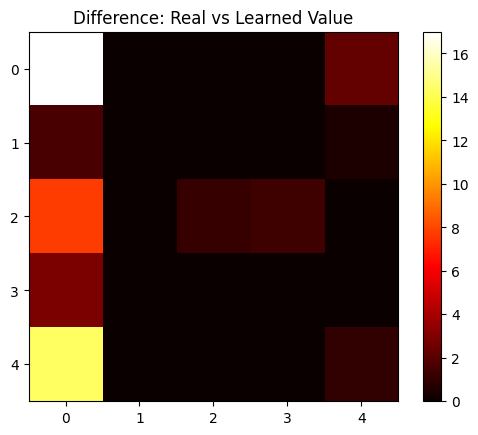

Average Diff 1.6176013037750363


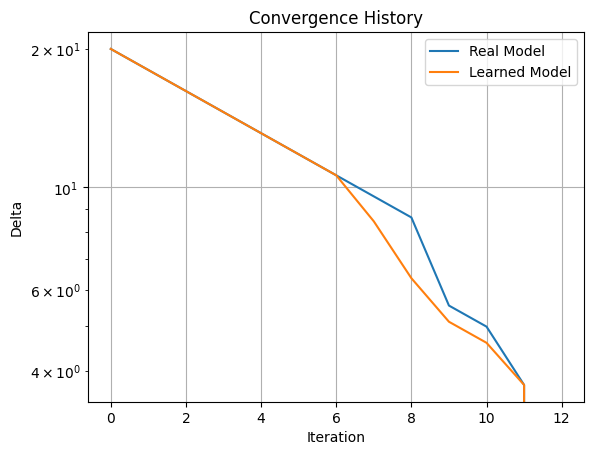

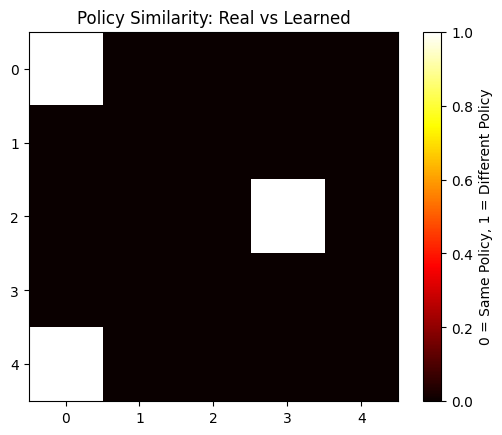

Number of difference = 82


In [ ]:
env = TaxiEnvironment()
vi_real = ValueIterationAgent(env, 0.9)
vi_real.value_iteration()
pi_real = PolicyIterationAgent(env, 0.9)
pi_real.run_policy_iteration()

vis.plot_value_difference(
    vi_real.value_function,
    vi_learned.value_function
)
print(f"Average Diff {np.mean(np.abs(vi_real.value_function - vi_learned.value_function))}")

vis.plot_convergence(
    [vi_real.convergence_history, vi_learned.convergence_history],
    ["Real Model", "Learned Model"]
)

vis.plot_policy_similarity(
    pi_real.policy,
    pi_learned.policy
)
print(f"Number of difference = {np.sum(np.array(pi_real.policy) != np.array(pi_learned.policy))}")





# **Analysis**

### **Value Function Accuracy**
The value functions of the learned model are close to the real model, indicating that the transition model approximates the environment well.

### **Convergence Behaviour**

the convergence behaviour of the learned model closely matches that of the real model, indicating that the transition model has been learned effectively, with only minor deviations due to estimation errors.

### **Policy Similarity Analysis**

The learned policy is largely similar to the optimal policy derived from the real model, with 418 out of 500 states matching.

the learned model captures the general behavior of the optimal policy, but some deviations remain due to limited exploration and estimation errors.

# **MountainCar**

In [5]:
import gymnasium as gym
import numpy as np

class MountainCarContinuousAdapter:
    def __init__(self, n_position_bins=50, n_velocity_bins=50):
        self.env = gym.make("MountainCarContinuous-v0")

        # Discretized actions
        self.actions = [-1.0, 0.0, 1.0]
        self.n_actions = len(self.actions)

        # Discretization config
        self.n_position_bins = n_position_bins
        self.n_velocity_bins = n_velocity_bins

        self.n_states = self.n_position_bins * self.n_velocity_bins

        # Bounds
        self.position_min = self.env.observation_space.low[0]
        self.position_max = self.env.observation_space.high[0]

        self.velocity_min = self.env.observation_space.low[1]
        self.velocity_max = self.env.observation_space.high[1]

        # Bin widths
        self.position_bin_width = (self.position_max - self.position_min) / self.n_position_bins
        self.velocity_bin_width = (self.velocity_max - self.velocity_min) / self.n_velocity_bins

    def _discretize(self, state):
        position, velocity = state

        pos_bin = int((position - self.position_min) / self.position_bin_width)
        vel_bin = int((velocity - self.velocity_min) / self.velocity_bin_width)

        pos_bin = np.clip(pos_bin, 0, self.n_position_bins - 1)
        vel_bin = np.clip(vel_bin, 0, self.n_velocity_bins - 1)

        state_index = pos_bin * self.n_velocity_bins + vel_bin
        return state_index

    def reset(self):
        state, _ = self.env.reset()
        return self._discretize(state)

    def step(self, action_index):
        real_action = self.actions[action_index]
        next_state, reward, terminated, truncated, _ = self.env.step([real_action])

        done = terminated or truncated
        return self._discretize(next_state), reward, done, {}

    def render(self):
        return self.env.render()

In [6]:
env = MountainCarContinuousAdapter()
model = TransitionModel(env.n_states, env.n_actions)

In [7]:
for episode in range(1000):
    state = env.reset()

    while True:
        action = np.random.randint(env.n_actions)

        next_state, reward, done, _ = env.step(action)

        model.update(state, action, reward, next_state, done)

        state = next_state

        if done:
            break

In [11]:
vi_agent = ValueIterationAgent(model, gamma=0.9)
iter = vi_agent.value_iteration()

print("VI done")
print("Iterations:", iter)
print("Last delta:", vi_agent.convergence_history[-1])
print("Mean value:", np.mean(vi_agent.value_function))
print("Max value:", np.max(vi_agent.value_function))

VI done
Iterations: 82
Last delta: 9.65178447997865e-06
Mean value: 4.520521775116173
Max value: 100.0


In [12]:
pi_agent = PolicyIterationAgent(model, gamma=0.9)
pi_iterations = pi_agent.run_policy_iteration()

print("PI done")
print("Iterations:", pi_iterations)
print("Mean value:", np.mean(pi_agent.value_function))
print("Max value:", np.max(pi_agent.value_function))

PI done
Iterations: 18
Mean value: 4.5205256312485105
Max value: 100.0


# **MountainCar Analysis**

### **Discretisation**
The MountainCarContinuous environment has a continuous state (position, velocity), but our algorithms need discrete states.

So, we divide the range of position and velocity into bins, and map each value to a bin.

- state_index = pos_bin * n_velocity_bins + vel_bin

### **Granularity Effect**
Few bins:
- Faster
- Less accurate

More bins:
- More accurate
- Slower (more states)

### **What Works**


1.   List item
2.   List item


Both algorithms successfully converged and produced very similar value estimates.
The mean and max values are almost identical, which shows that the learned policy is stable and consistent.

### **Why Value Iteration needs many iterations (MountainCar)**
- Reward is sparse (only at the goal)
- Value must propagate step-by-step from goal to start
- Discretised space is large (400 states)
- Information spreads slowly across states

### **Policy Iteration behaviour**

Policy Iteration converges faster than Value Iteration because it improves the policy directly, requiring fewer iterations to stabilise.

### **What Fails / Limitations**

- The environment is still approximated (discretised)
- Some precision is lost from continuous state mapping
- Results depend heavily on bin size





# **Conceptual Questions**
### **5. How does γ influence agent behaviour?**

γ controls how much the agent cares about future rewards.

- Low γ (e.g., 0.5): agent is short-sighted and prefers immediate rewards.
- High γ (e.g., 0.99): agent is long-sighted and considers future rewards more.

### **6. Relationship between Value Iteration and Policy Iteration**

Both methods aim to find the optimal policy.

- Value Iteration directly updates the value function and derives policy at the end.
- Policy Iteration alternates between evaluating a policy and improving it.

### **7. Why is exploration unnecessary in Dynamic Programming?**

Dynamic Programming assumes a known model of the environment (P and R).

So:
- No need to explore
- All state transitions are already known

the agent can compute optimal policy directly.

### **8. Planning vs Learning in Reinforcement Learning**

- Planning: uses a known model of the environment to compute optimal policy (e.g., VI, PI).
- Learning: learns from interaction without knowing the model (e.g.,MC methods).

### **9. Model-based vs Model-free learning**

- Model-based: agent has access to transition probabilities and rewards.
- Model-free: agent learns only from experience without knowing the model.

Model-based methods are more sample-efficient.
Model-free methods are more flexible.

### **10. What if ε-greedy is used in DP?**

Dynamic Programming does not need exploration.

If ε-greedy is added:
- It introduces randomness
- Slows convergence
- Makes updates less optimal

### **11. Why is one greedy policy improvement step not enough?**
It is not sufficient because:
- The value function may not be fully converged yet
- The estimated values of next states may still be inaccurate

### **12. Can DP be used for GTA V?**
No.Because:
- State space is extremely large (continuous, high-dimensional)
- No full model is available
- Computational cost is impossible

DP works only in small, fully known environments.